ДАТАСЕТ ДИАБЕТА
Первые 5 строк датасета:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

ИНФОРМАЦИЯ О ДАТАСЕТЕ:
Размер: (768, 9) строк, 9 колонок
Колонки: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Уникальные значения Outcome: [0, 1]

ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ


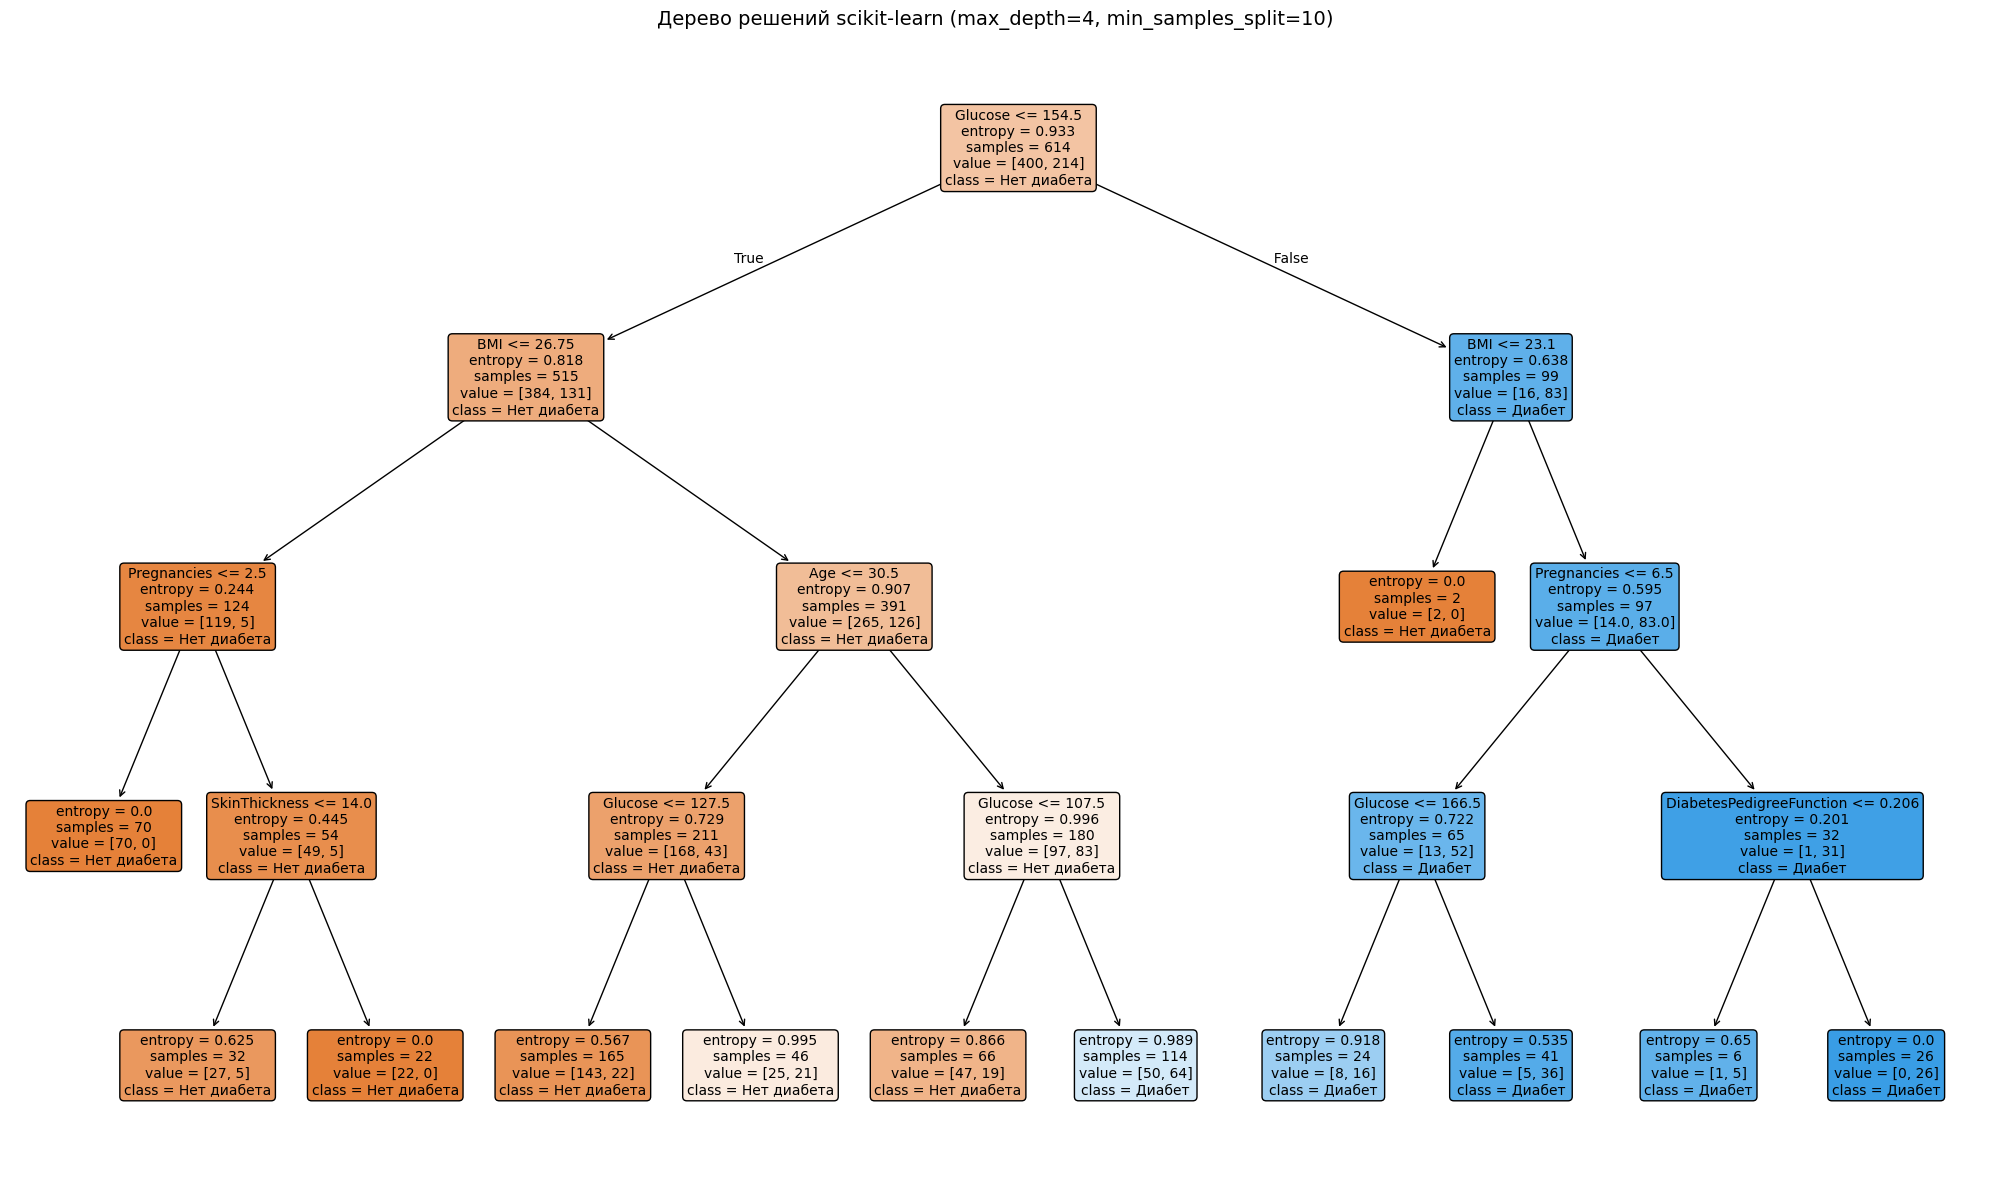


АНАЛИЗ ЛИСТЬЕВ SCIKIT-LEARN ДЕРЕВА

Анализ листьев (scikit-learn):
  Лист 3: 20 образцов, доля класса 1 = 0.000, предсказанный класс = 0
  Лист 5: 9 образцов, доля класса 1 = 0.000, предсказанный класс = 0
  Лист 6: 9 образцов, доля класса 1 = 0.222, предсказанный класс = 0
  Лист 9: 38 образцов, доля класса 1 = 0.184, предсказанный класс = 0
  Лист 10: 13 образцов, доля класса 1 = 0.308, предсказанный класс = 0
  Лист 12: 15 образцов, доля класса 1 = 0.267, предсказанный класс = 0
  Лист 13: 27 образцов, доля класса 1 = 0.815, предсказанный класс = 1
  Лист 18: 3 образцов, доля класса 1 = 0.333, предсказанный класс = 1
  Лист 19: 11 образцов, доля класса 1 = 0.818, предсказанный класс = 1
  Лист 21: 2 образцов, доля класса 1 = 0.000, предсказанный класс = 1
  Лист 22: 7 образцов, доля класса 1 = 0.714, предсказанный класс = 1

ВАЖНОСТЬ ПРИЗНАКОВ В SCIKIT-LEARN

Важность признаков (scikit-learn):
  Pregnancies: 0.0542
  Glucose: 0.5884
  BloodPressure: 0.0000
  SkinThickness: 0.0206
 

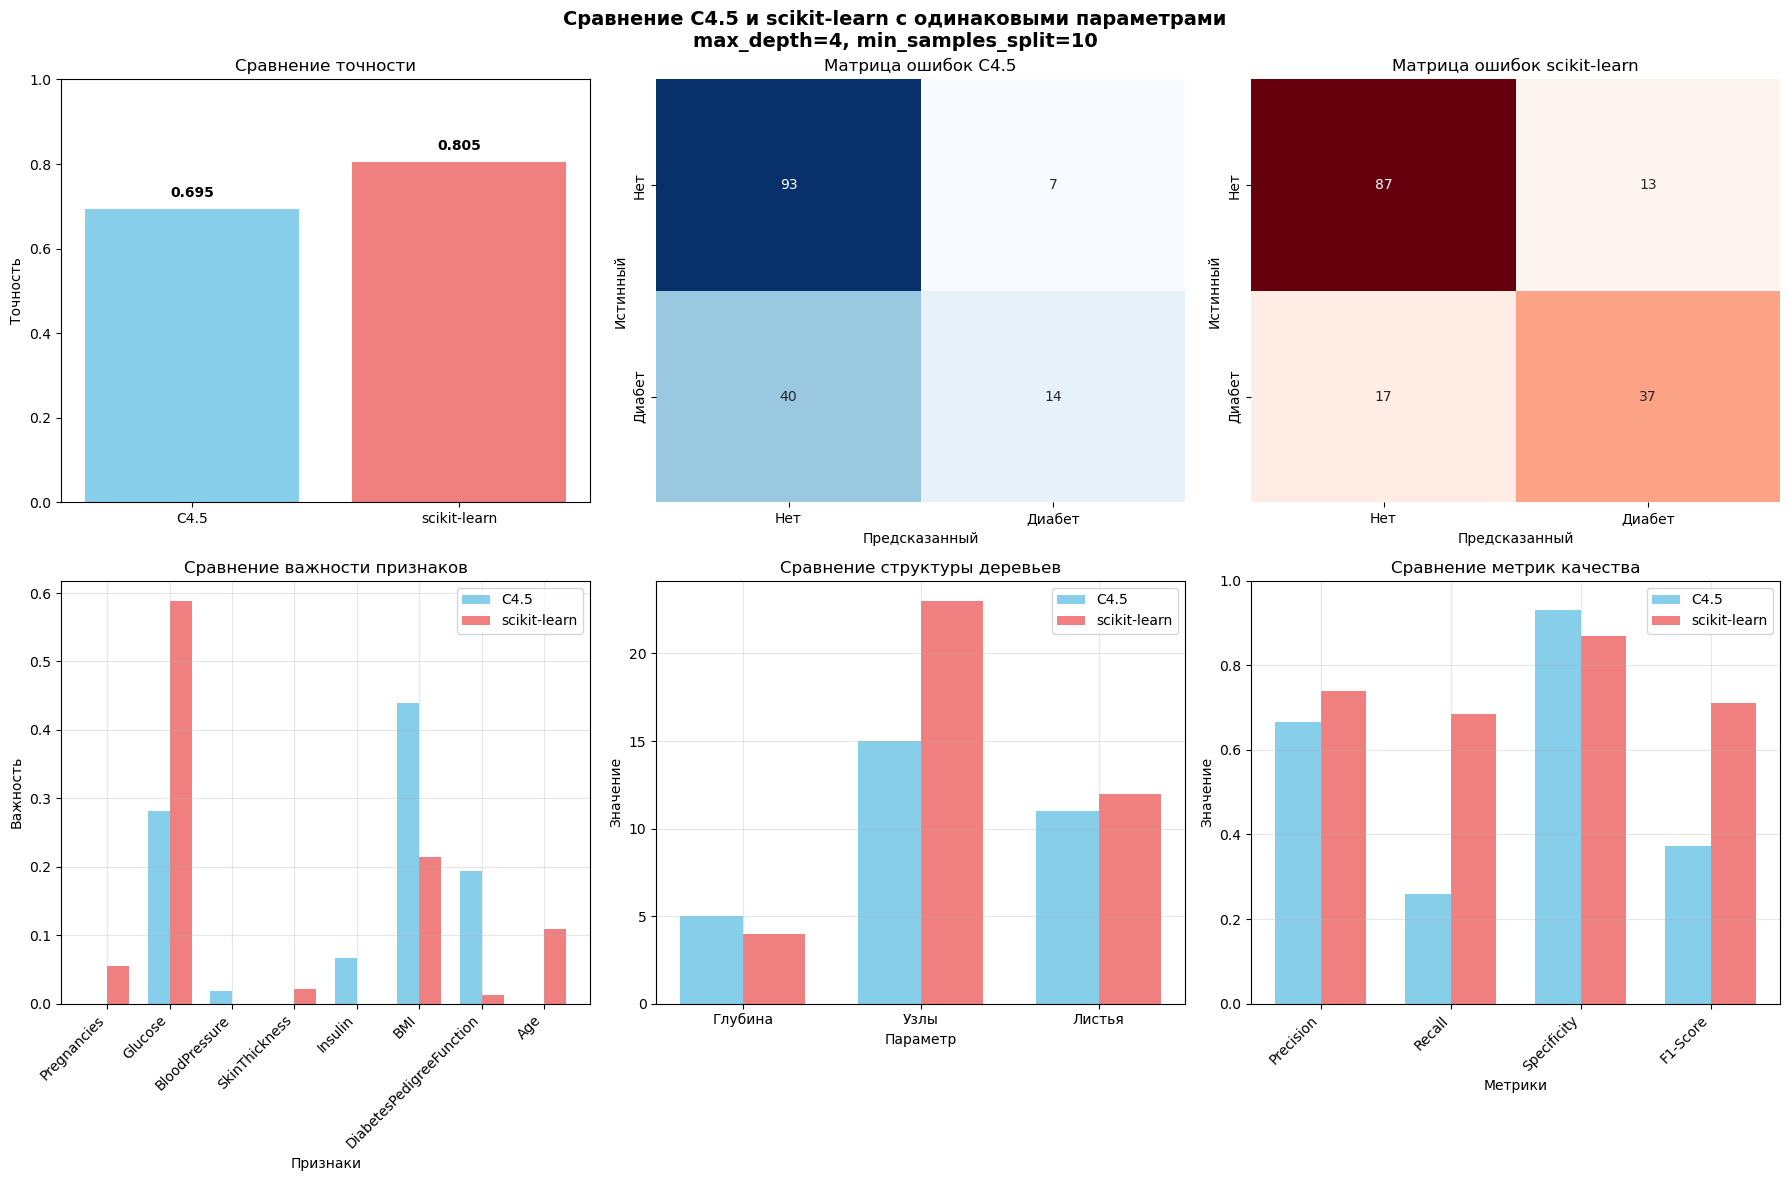


ИТОГОВЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

1. ОСНОВНЫЕ ВЫВОДЫ:
   • C4.5 показывает точность 0.6948, scikit-learn - 0.8052
   • Разница в точности: 0.1104 (15.9%)

2. АНАЛИЗ СТРУКТУРЫ:
   • C4.5 создал дерево из 15 узлов (глубина 5)
   • scikit-learn создал дерево из 23 узлов (глубина 4)
   • Отношение сложности: scikit-learn в 1.5 раз сложнее

3. ВАЖНОСТЬ ПРИЗНАКОВ:
   • Топ-3 признаков в C4.5: BMI (0.439) Glucose (0.282) DiabetesPedigreeFunction (0.194) 
   • Топ-3 признаков в scikit-learn: Glucose (0.588) BMI (0.214) Age (0.110) 

4. РЕКОМЕНДАЦИИ:
   • Для улучшения C4.5: оптимизировать поиск порогов, добавить post-pruning
   • Для медицинских задач важны recall и specificity для минимизации ошибок
   • Можно экспериментировать с параметрами для улучшения результатов

АНАЛИЗ ЗАВЕРШЕН

ГРАФИЧЕСКАЯ ВИЗУАЛИЗАЦИЯ РУЧНОГО ДЕРЕВА C4.5


<Figure size 1600x1000 with 0 Axes>

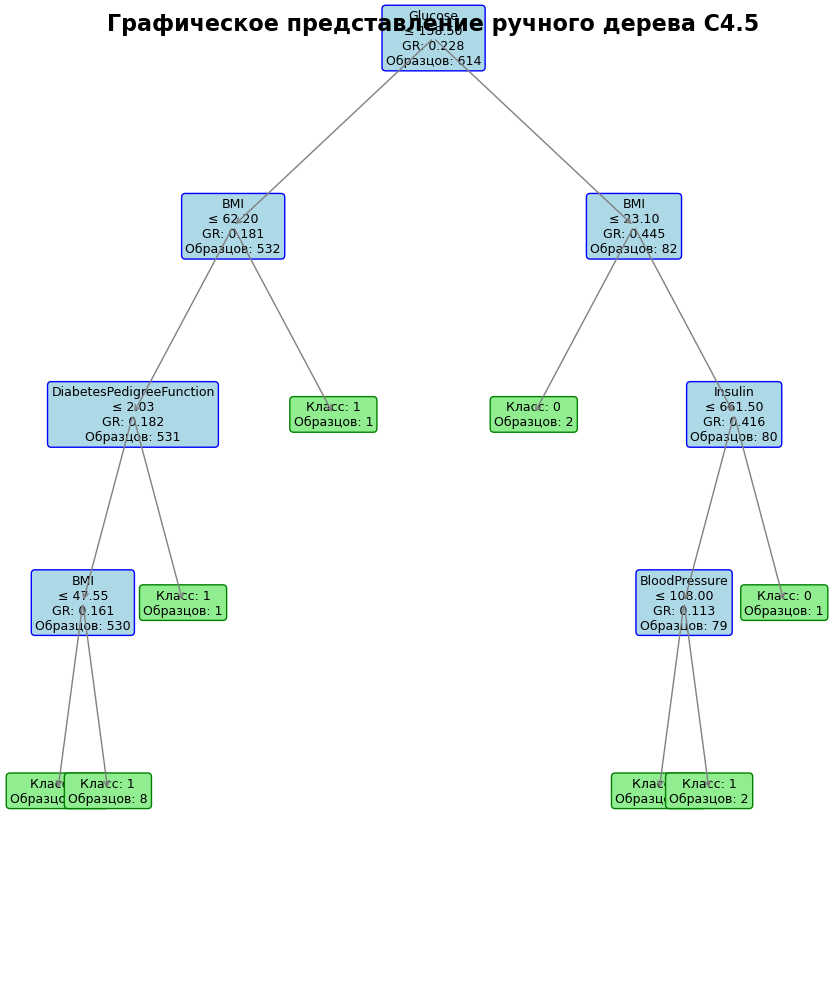

In [1]:
# ============================================
# ИМПОРТ БИБЛИОТЕК
# ============================================

# Импорт библиотеки pandas для работы с табличными данными
import pandas as pd
# Импорт numpy для числовых вычислений
import numpy as np
# Импорт matplotlib для построения графиков
import matplotlib.pyplot as plt
# Импорт функций для разделения данных и оценки моделей из scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Импорт классификатора дерева решений и функции для его визуализации
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Импорт seaborn для улучшенной визуализации
import seaborn as sns
# Импорт Counter для подсчета элементов
from collections import Counter
# Импорт математических функций
import math

# ============================================
# ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================

# Максимальная глубина дерева (ограничивает сложность модели)
MAX_DEPTH = 4
# Минимальное количество образцов для разбиения узла (предотвращает переобучение)
MIN_SAMPLES_SPLIT = 10
# Минимальный Gain Ratio для C4.5 (критерий остановки роста дерева)
MIN_GAIN_RATIO = 0.001
# Минимальное уменьшение неопределенности для scikit-learn (аналог min_gain_ratio)
MIN_IMPURITY_DECREASE = 0.001
# Seed для генератора случайных чисел (обеспечивает воспроизводимость)
RANDOM_STATE = 42

# ============================================
# ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ============================================

# Загрузка датасета диабета из CSV файла в DataFrame
df = pd.read_csv('diabetes.csv')

# Вывод разделительной линии для лучшей читаемости вывода
print("=" * 70)
print("ДАТАСЕТ ДИАБЕТА")
print("=" * 70)
# Показать первые 5 строк датасета для предварительного ознакомления
print("Первые 5 строк датасета:")
print(df.head())

# Вывод основной информации о датасете
print(f"\nИНФОРМАЦИЯ О ДАТАСЕТЕ:")
# Размер датасета (количество строк и столбцов)
print(f"Размер: {df.shape} строк, {df.shape[1]} колонок")
# Список названий всех столбцов
print(f"Колонки: {df.columns.tolist()}")
# Уникальные значения целевой переменной Outcome (диагноз диабета)
print(f"Уникальные значения Outcome: {sorted(df['Outcome'].unique())}")

# ============================================
# ВЫВОД ИНФОРМАЦИИ ОБ ОБЩИХ ПАРАМЕТРАХ
# ============================================

print("\n" + "=" * 70)
print("ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ")
print("=" * 70)
# Вывод всех заданных гиперпараметров
print(f"MAX_DEPTH = {MAX_DEPTH}")
print(f"MIN_SAMPLES_SPLIT = {MIN_SAMPLES_SPLIT}")
print(f"MIN_GAIN_RATIO = {MIN_GAIN_RATIO} (для C4.5)")
print(f"MIN_IMPURITY_DECREASE = {MIN_IMPURITY_DECREASE} (для scikit-learn)")
print(f"RANDOM_STATE = {RANDOM_STATE}")

# ============================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
# ============================================

# Создание списка признаков (все колонки кроме целевой 'Outcome')
features = [col for col in df.columns if col != 'Outcome']
# Выделение матрицы признаков X (значения всех признаков)
X = df[features].values
# Выделение вектора целевых переменных y (диагнозы)
y = df['Outcome'].values

# Вывод информации о признаках
print(f"\nПРИЗНАКИ ДЛЯ ОБУЧЕНИЯ ({len(features)} шт): {features}")
print(f"РАСПРЕДЕЛЕНИЕ КЛАССОВ В ДАТАСЕТЕ:")
# Подсчет и вывод количества образцов класса 0 (нет диабета)
print(f"  • Класс 0 (нет диабета): {np.sum(y == 0)} образцов ({np.mean(y == 0)*100:.1f}%)")
# Подсчет и вывод количества образцов класса 1 (диабет)
print(f"  • Класс 1 (диабет): {np.sum(y == 1)} образцов ({np.mean(y == 1)*100:.1f}%)")

# Разделение данных на обучающую (80%) и тестовую (20%) выборки
# stratify=y обеспечивает сохранение пропорций классов в выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"\nРАЗМЕРЫ ВЫБОРОК ПОСЛЕ РАЗДЕЛЕНИЯ:")
print(f"Обучающая выборка: {X_train.shape} ({X_train.shape[0]} образцов, {X_train.shape[1]} признаков)")
print(f"Тестовая выборка: {X_test.shape} ({X_test.shape[0]} образцов, {X_test.shape[1]} признаков)")

# Разделение обучающей выборки по классам для дальнейшего анализа
x1_train = X_train[y_train == 1]  # Образцы с диабетом
x0_train = X_train[y_train == 0]  # Образцы без диабета

print(f"\nРАСПРЕДЕЛЕНИЕ КЛАССОВ В ОБУЧАЮЩЕЙ ВЫБОРКЕ:")
print(f"  • Образцов с диабетом: {len(x1_train)}")
print(f"  • Образцов без диабета: {len(x0_train)}")

# ============================================
# КЛАСС УЗЛА ДЕРЕВА C4.5 (С ДОБАВЛЕННЫМИ МЕТОДАМИ ИЗ CART)
# ============================================

class NodeC45:
    # Конструктор класса узла дерева
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None, 
                 is_leaf=False, split_info=0, gain_ratio=0, samples=None):
        # Основные параметры как в CART
        self.feature_index = feature_index  # Индекс признака для разбиения
        self.threshold = threshold          # Пороговое значение для разбиения
        self.left = left                    # Левый потомок (значения <= threshold)
        self.right = right                  # Правый потомок (значения > threshold)
        self.value = value                  # Значение в листовом узле (предсказанный класс)
        
        # Дополнительные параметры для C4.5
        self.is_leaf = is_leaf              # Флаг листового узла
        self.split_info = split_info        # Информация разбиения (Split Information)
        self.gain_ratio = gain_ratio        # Коэффициент усиления (Gain Ratio)
        self.samples = samples              # Количество образцов в узле
    
    # Метод для проверки, является ли узел листовым
    def is_leaf_node(self):
        """Проверяет, является ли узел листовым (для совместимости с CART методами)"""
        return self.is_leaf

# ============================================
# КЛАСС ДЕРЕВА РЕШЕНИЙ C4.5 (С ДОБАВЛЕННЫМИ МЕТОДАМИ ИЗ CART)
# ============================================

class C45DecisionTree:
    # Конструктор класса дерева C4.5
    def __init__(self, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES_SPLIT, 
                 min_gain_ratio=MIN_GAIN_RATIO):
        self.max_depth = max_depth           # Максимальная глубина дерева
        self.min_samples_split = min_samples_split  # Минимальное количество образцов для разбиения
        self.min_gain_ratio = min_gain_ratio        # Минимальный Gain Ratio
        self.root = None                     # Корневой узел дерева
        self.feature_names = None            # Имена признаков для визуализации
    
    # ============================================
    # ОСНОВНЫЕ МЕТОДЫ C4.5 (ОСТАЮТСЯ БЕЗ ИЗМЕНЕНИЙ)
    # ============================================
    
    def calculate_entropy(self, y):
        """Вычисление энтропии (метод C4.5)"""
        if len(y) == 0:  # Если нет данных, энтропия равна 0
            return 0
        # Получение уникальных классов и их количества
        _, counts = np.unique(y, return_counts=True)
        # Вычисление вероятностей каждого класса
        probabilities = counts / len(y)
        # Формула энтропии Шеннона: -∑ p_i * log2(p_i)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy
    
    def calculate_split_info(self, splits):
        """Вычисление информации разбиения (метод C4.5)"""
        total = sum(len(split) for split in splits)  # Общее количество образцов
        if total == 0:
            return 0
        split_info = 0
        for split in splits:
            if len(split) > 0:
                ratio = len(split) / total  # Доля образцов в данном разбиении
                split_info -= ratio * np.log2(ratio + 1e-10)  # Формула информации разбиения
        return split_info
    
    def find_best_threshold(self, feature_values, y):
        """Поиск лучшего порога (метод C4.5)"""
        best_gain_ratio = -1  # Инициализация лучшего Gain Ratio
        best_threshold = None  # Лучший порог разбиения
        best_left_indices = None  # Индексы левого подмножества
        best_right_indices = None  # Индексы правого подмножества
        best_split_info = 0  # Информация разбиения
        
        # Получение уникальных значений признака
        sorted_values = np.unique(feature_values)
        if len(sorted_values) <= 1:  # Если все значения одинаковые, разбиение невозможно
            return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
        
        # Перебор всех возможных порогов (середин между соседними уникальными значениями)
        for i in range(len(sorted_values) - 1):
            threshold = (sorted_values[i] + sorted_values[i + 1]) / 2
            
            # Разделение данных по порогу
            left_indices = feature_values <= threshold
            right_indices = feature_values > threshold
            
            # Проверка, что оба подмножества не пустые
            if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
                continue
            
            # Вычисление энтропии родительского узла
            entropy_parent = self.calculate_entropy(y)
            # Энтропия левого подмножества
            entropy_left = self.calculate_entropy(y[left_indices])
            # Энтропия правого подмножества
            entropy_right = self.calculate_entropy(y[right_indices])
            
            # Количество образцов в подмножествах
            n_left = np.sum(left_indices)
            n_right = np.sum(right_indices)
            total_samples = n_left + n_right
            
            # Вычисление информационного выигрыша (Information Gain)
            info_gain = entropy_parent - (n_left/total_samples * entropy_left + 
                                         n_right/total_samples * entropy_right)
            
            # Вычисление информации разбиения
            split_info = self.calculate_split_info([y[left_indices], y[right_indices]])
            
            # Вычисление Gain Ratio (делим Information Gain на Split Information)
            if split_info > 0:
                gain_ratio = info_gain / split_info
            else:
                gain_ratio = 0
            
            # Обновление лучшего разбиения, если найден лучший Gain Ratio
            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_threshold = threshold
                best_left_indices = left_indices
                best_right_indices = right_indices
                best_split_info = split_info
        
        # Возврат параметров лучшего разбиения
        return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
    
    def find_best_split(self, X, y):
        """Поиск лучшего разбиения (метод C4.5)"""
        best_gain_ratio = -1  # Инициализация лучшего Gain Ratio
        best_split = {}  # Словарь с параметрами лучшего разбиения
        n_samples, n_features = X.shape  # Размеры данных
        
        # Проверка минимального количества образцов для разбиения
        if n_samples < self.min_samples_split:
            return best_split
        
        # Вычисление текущей энтропии узла
        current_entropy = self.calculate_entropy(y)
        print(f"  Текущая энтропия: {current_entropy:.4f}")
        
        # Перебор всех признаков для поиска лучшего разбиения
        for feature_index in range(n_features):
            # Получение имени признака для вывода
            feature_name = self.feature_names[feature_index] if self.feature_names else f"Feature_{feature_index}"
            print(f"  Признак {feature_name}:", end=" ")
            
            # Поиск лучшего порога для текущего признака
            feature_values = X[:, feature_index]
            gain_ratio, threshold, left_indices, right_indices, split_info = self.find_best_threshold(feature_values, y)
            
            # Обновление лучшего разбиения, если найден лучший Gain Ratio
            if gain_ratio > best_gain_ratio and threshold is not None:
                best_gain_ratio = gain_ratio
                best_split = {
                    'feature_index': feature_index,
                    'threshold': threshold,
                    'left_indices': left_indices,
                    'right_indices': right_indices,
                    'gain_ratio': gain_ratio,
                    'split_info': split_info,
                    'info_gain': current_entropy - (np.sum(left_indices)/n_samples * self.calculate_entropy(y[left_indices]) + 
                                                   np.sum(right_indices)/n_samples * self.calculate_entropy(y[right_indices])),
                    'is_categorical': False
                }
        
        # Вывод информации о лучшем разбиении
        if best_split:
            feature_name = self.feature_names[best_split['feature_index']] if self.feature_names else f"Feature_{best_split['feature_index']}"
            print(f"  Лучшее разбиение: Признак '{feature_name}', "
                  f"Порог={best_split['threshold']:.4f}, Gain Ratio={best_split['gain_ratio']:.4f}, "
                  f"Split Info={best_split['split_info']:.4f}")
        
        return best_split
    
    def build_tree(self, X, y, depth=0):
        """Рекурсивное построение дерева (метод C4.5)"""
        # Условия остановки рекурсии:
        # 1. Достигнута максимальная глубина
        # 2. Слишком мало образцов для разбиения
        # 3. Все образцы принадлежат одному классу
        # 4. Энтропия очень низкая (почти чистый узел)
        if (depth >= self.max_depth or 
            len(y) < self.min_samples_split or 
            len(np.unique(y)) == 1 or
            self.calculate_entropy(y) < 0.01):
            
            # Определение класса листа (мажоритарный класс)
            if len(y) == 0:
                value = 0
            else:
                value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            leaf_entropy = self.calculate_entropy(y)
            print(f"Создан лист на глубине {depth}: класс={value}, образцов={len(y)}, энтропия={leaf_entropy:.4f}")
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        print(f"\nУровень {depth}: {len(y)} образцов")
        # Поиск лучшего разбиения для текущего узла
        best_split = self.find_best_split(X, y)
        
        # Если не найдено подходящего разбиения или Gain Ratio слишком мал, создаем лист
        if not best_split or best_split['gain_ratio'] < self.min_gain_ratio:
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            leaf_entropy = self.calculate_entropy(y)
            print(f"Недостаточный Gain Ratio, создан лист: класс={value}, энтропия={leaf_entropy:.4f}")
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # Создание внутреннего узла с параметрами лучшего разбиения
        node = NodeC45(
            feature_index=best_split['feature_index'],
            threshold=best_split['threshold'],
            gain_ratio=best_split['gain_ratio'],
            split_info=best_split['split_info'],
            samples=len(y)
        )
        
        # Рекурсивное построение левого поддерева
        left_subtree = self.build_tree(
            X[best_split['left_indices']], 
            y[best_split['left_indices']], 
            depth + 1
        )
        
        # Рекурсивное построение правого поддерева
        right_subtree = self.build_tree(
            X[best_split['right_indices']], 
            y[best_split['right_indices']], 
            depth + 1
        )
        
        # Присоединение поддеревьев к текущему узлу
        node.left = left_subtree
        node.right = right_subtree
        
        return node
    
    def fit(self, X, y, feature_names=None):
        """Обучение дерева (метод C4.5)"""
        # Сохранение имен признаков для визуализации
        if feature_names is not None:
            self.feature_names = feature_names
        else:
            self.feature_names = [f"Признак_{i}" for i in range(X.shape[1])]
        # Построение дерева от корня
        self.root = self.build_tree(X, y)
    
    def predict_sample(self, x, node):
        """Рекурсивное предсказание для одного образца (метод C4.5)"""
        if node.is_leaf:  # Если достигли листа, возвращаем его значение
            return node.value
        
        # Рекурсивный спуск по дереву в зависимости от значения признака
        if x[node.feature_index] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    def predict(self, X):
        """Предсказание для всего набора данных (метод C4.5)"""
        predictions = []
        for x in X:  # Для каждого образца в наборе данных
            predictions.append(self.predict_sample(x, self.root))
        return np.array(predictions)
    
    # ============================================
    # ДОБАВЛЕННЫЕ МЕТОДЫ ИЗ CART ДЛЯ ВИЗУАЛИЗАЦИИ И АНАЛИЗА
    # ============================================
    
    def print_tree(self, node=None, depth=0, feature_names=None):
        """Визуализация дерева в текстовом виде (метод из CART)"""
        if feature_names is None:
            feature_names = self.feature_names if self.feature_names else [f"Feature_{i}" for i in range(len(features))]
        if node is None:
            node = self.root  # Начинаем с корня
        
        indent = "    " * depth  # Отступ для визуализации иерархии
        
        if node.is_leaf:  # Вывод листового узла
            print(f"{indent}Класс: {node.value}")
        else:  # Вывод внутреннего узла
            feature_name = feature_names[node.feature_index]
            if hasattr(node, 'gain_ratio'):  # Для C4.5 выводим также Gain Ratio
                print(f"{indent}{feature_name} <= {node.threshold:.2f} [Gain Ratio: {node.gain_ratio:.4f}]")
            else:
                print(f"{indent}{feature_name} <= {node.threshold:.2f}")
            
            # Рекурсивный вывод левого поддерева
            self.print_tree(node.left, depth + 1, feature_names)
            
            if hasattr(node, 'gain_ratio'):
                print(f"{indent}{feature_name} > {node.threshold:.2f} [Gain Ratio: {node.gain_ratio:.4f}]")
            else:
                print(f"{indent}{feature_name} > {node.threshold:.2f}")
            
            # Рекурсивный вывод правого поддерева
            self.print_tree(node.right, depth + 1, feature_names)
    
    def get_depth(self, node=None):
        """Вычисление глубины дерева (метод из CART)"""
        if node is None:
            node = self.root
        
        if node.is_leaf:  # Глубина листа = 1
            return 1
        
        # Глубина узла = 1 + максимальная глубина поддеревьев
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))
    
    def get_node_count(self, node=None):
        """Подсчет общего количества узлов (метод из CART)"""
        if node is None:
            node = self.root
        
        if node.is_leaf:  # Лист - это 1 узел
            return 1
        
        # Количество узлов = 1 (текущий) + узлы левого поддерева + узлы правого поддерева
        return 1 + self.get_node_count(node.left) + self.get_node_count(node.right)
    
    def analyze_leaves(self, X, y, model_type="C4.5"):
        """Анализ распределения классов в листьях дерева (метод из CART)"""
        print(f"\nАнализ листьев ({model_type}):")
        
        leaves = []  # Список для хранения информации о листьях
        
        def collect_leaves(node, leaf_id=0):
            if node is None:
                return leaf_id
            
            if node.is_leaf:  # Если узел - лист, добавляем его в список
                leaves.append({
                    'id': leaf_id,
                    'node': node,
                    'class': node.value
                })
                return leaf_id + 1
            else:  # Иначе рекурсивно обходим поддеревья
                next_id = collect_leaves(node.left, leaf_id)
                next_id = collect_leaves(node.right, next_id)
                return next_id
        
        collect_leaves(self.root)  # Сбор всех листьев дерева
        
        leaf_assignments = []  # Для каждого образца запоминаем, в какой лист он попадает
        for x in X:
            current_node = self.root
            # Спуск по дереву до листа
            while not current_node.is_leaf:
                if x[current_node.feature_index] <= current_node.threshold:
                    current_node = current_node.left
                else:
                    current_node = current_node.right
            # Поиск ID листа в списке листьев
            for leaf in leaves:
                if leaf['node'] == current_node:
                    leaf_assignments.append(leaf['id'])
                    break
        
        leaf_assignments = np.array(leaf_assignments)
        unique_leaves = np.unique(leaf_assignments)  # Уникальные ID листьев
        
        # Вывод статистики по каждому листу
        for leaf_id in unique_leaves:
            leaf_indices = leaf_assignments == leaf_id
            leaf_samples = y[leaf_indices]
            if len(leaf_samples) > 0:
                class_1_ratio = np.sum(leaf_samples == 1) / len(leaf_samples)
                leaf_info = leaves[leaf_id]
                print(f"  Лист {leaf_id}: {len(leaf_samples)} образцов, "
                      f"доля класса 1 = {class_1_ratio:.3f}, предсказанный класс = {leaf_info['class']}")
    
    def get_feature_importance(self):
        """Вычисление важности признаков (аналог scikit-learn)"""
        if self.root is None:
            return None
        
        feature_importance = np.zeros(len(self.feature_names))  # Инициализация массива важностей
        
        def traverse(node):
            if node.is_leaf:  # В листьях нет признаков для разбиения
                return
            
            # Важность признака = Gain Ratio * количество образцов в узле
            if hasattr(node, 'gain_ratio') and node.gain_ratio > 0 and hasattr(node, 'samples'):
                feature_importance[node.feature_index] += node.gain_ratio * node.samples
            
            # Рекурсивный обход поддеревьев
            if node.left:
                traverse(node.left)
            if node.right:
                traverse(node.right)
        
        traverse(self.root)  # Обход дерева от корня
        
        # Нормализация важностей (сумма = 1)
        if np.sum(feature_importance) > 0:
            feature_importance = feature_importance / np.sum(feature_importance)
        
        return feature_importance

# ============================================
# ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ C4.5
# ============================================

print("\n" + "=" * 70)
print("ОБУЧЕНИЕ МОДЕЛИ C4.5 С ОБЩИМИ ПАРАМЕТРАМИ")
print("=" * 70)

print(f"Параметры C4.5:")
print(f"  • max_depth: {MAX_DEPTH}")
print(f"  • min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  • min_gain_ratio: {MIN_GAIN_RATIO}")

# Создание и обучение модели C4.5
c45_tree = C45DecisionTree(
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_gain_ratio=MIN_GAIN_RATIO
)

c45_tree.fit(X_train, y_train, feature_names=features)

# Предсказание на тестовой выборке
y_pred_c45 = c45_tree.predict(X_test)
# Вычисление точности (accuracy)
accuracy_c45 = accuracy_score(y_test, y_pred_c45)
# Получение глубины дерева
c45_depth = c45_tree.get_depth()
# Получение количества узлов в дереве
c45_nodes = c45_tree.get_node_count()

# Вывод результатов C4.5
print(f"\nРЕЗУЛЬТАТЫ C4.5:")
print(f"  Точность: {accuracy_c45:.4f}")
print(f"  Глубина дерева: {c45_depth}")
print(f"  Количество узлов: {c45_nodes}")
print(f"  Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_c45))
print(f"\n  Отчет о классификации:")
print(classification_report(y_test, y_pred_c45, target_names=['Нет диабета', 'Диабет']))

# ============================================
# ВИЗУАЛИЗАЦИЯ ДЕРЕВА C4.5 (ИСПОЛЬЗУЕМ ДОБАВЛЕННЫЕ МЕТОДЫ)
# ============================================

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ ДЕРЕВА C4.5")
print("=" * 70)

print("\nСтруктура дерева C4.5 (текстовое представление):")
print("-" * 50)
c45_tree.print_tree()  # Вывод дерева в текстовом виде

# Анализ листьев дерева C4.5
c45_tree.analyze_leaves(X_test, y_test, "C4.5")

# ============================================
# ВАЖНОСТЬ ПРИЗНАКОВ В C4.5
# ============================================

print("\n" + "=" * 70)
print("ВАЖНОСТЬ ПРИЗНАКОВ В C4.5")
print("=" * 70)

c45_feature_importance = c45_tree.get_feature_importance()
if c45_feature_importance is not None:
    print("\nВажность признаков (C4.5):")
    for i, (feature, importance) in enumerate(zip(features, c45_feature_importance)):
        print(f"  {feature}: {importance:.4f}")

# ============================================
# ОБУЧЕНИЕ И ОЦЕНКА БИБЛИОТЕЧНОЙ РЕАЛИЗАЦИИ
# ============================================

print("\n" + "=" * 70)
print("ОБУЧЕНИЕ SCIKIT-LEARN С ОБЩИМИ ПАРАМЕТРАМИ")
print("=" * 70)

print(f"Параметры scikit-learn:")
print(f"  • criterion: 'entropy' (как в C4.5)")
print(f"  • max_depth: {MAX_DEPTH}")
print(f"  • min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  • min_impurity_decrease: {MIN_IMPURITY_DECREASE} (аналог min_gain_ratio)")
print(f"  • random_state: {RANDOM_STATE}")

# Создание и обучение модели scikit-learn
sklearn_tree = DecisionTreeClassifier(
    criterion='entropy',  # Используем энтропию как и в C4.5
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_impurity_decrease=MIN_IMPURITY_DECREASE,
    random_state=RANDOM_STATE
)

sklearn_tree.fit(X_train, y_train)

# Предсказание и оценка scikit-learn
y_pred_sklearn = sklearn_tree.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
sklearn_depth = sklearn_tree.get_depth()
sklearn_nodes = sklearn_tree.tree_.node_count

# Вывод результатов scikit-learn
print(f"\nРЕЗУЛЬТАТЫ SCIKIT-LEARN:")
print(f"  Точность: {accuracy_sklearn:.4f}")
print(f"  Глубина дерева: {sklearn_depth}")
print(f"  Количество узлов: {sklearn_nodes}")
print(f"  Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_sklearn))

# ============================================
# ВИЗУАЛИЗАЦИЯ ДЕРЕВА SCIKIT-LEARN
# ============================================

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ ДЕРЕВА SCIKIT-LEARN")
print("=" * 70)

# Создание графической визуализации дерева
plt.figure(figsize=(20, 12))
plot_tree(sklearn_tree, 
          feature_names=features,
          class_names=['Нет диабета', 'Диабет'],
          filled=True,      # Заливка цветом по классам
          rounded=True,     # Скругленные углы
          fontsize=10)
plt.title(f'Дерево решений scikit-learn (max_depth={MAX_DEPTH}, min_samples_split={MIN_SAMPLES_SPLIT})', fontsize=14)
plt.tight_layout()
plt.show()  # Отображение графика

# ============================================
# АНАЛИЗ ЛИСТЬЕВ SCIKIT-LEARN ДЕРЕВА
# ============================================

print("\n" + "=" * 70)
print("АНАЛИЗ ЛИСТЬЕВ SCIKIT-LEARN ДЕРЕВА")
print("=" * 70)

def analyze_sklearn_leaves(tree, X, y):
    """Анализ листьев для scikit-learn дерева (аналог метода из CART)"""
    print(f"\nАнализ листьев (scikit-learn):")
    # Получение индексов листьев, в которые попадают образцы
    leaf_predictions = tree.apply(X)
    unique_leaves = np.unique(leaf_predictions)
    
    for leaf in unique_leaves:
        leaf_indices = leaf_predictions == leaf
        leaf_samples = y[leaf_indices]
        if len(leaf_samples) > 0:
            class_1_ratio = np.sum(leaf_samples == 1) / len(leaf_samples)
            # Получаем предсказание для этого листа
            leaf_prediction = tree.predict(X[leaf_indices][:1])[0] if len(leaf_indices) > 0 else -1
            print(f"  Лист {leaf}: {len(leaf_samples)} образцов, "
                  f"доля класса 1 = {class_1_ratio:.3f}, предсказанный класс = {leaf_prediction}")

analyze_sklearn_leaves(sklearn_tree, X_test, y_test)

# ============================================
# ВАЖНОСТЬ ПРИЗНАКОВ В SCIKIT-LEARN
# ============================================

print("\n" + "=" * 70)
print("ВАЖНОСТЬ ПРИЗНАКОВ В SCIKIT-LEARN")
print("=" * 70)

sklearn_feature_importance = sklearn_tree.feature_importances_
print("\nВажность признаков (scikit-learn):")
for i, (feature, importance) in enumerate(zip(features, sklearn_feature_importance)):
    print(f"  {feature}: {importance:.4f}")

# ============================================
# СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ
# ============================================

print("\n" + "=" * 70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ")
print("=" * 70)

# Вывод заголовка таблицы сравнения
print(f"\n{'Модель':<20} {'Точность':<12} {'Глубина':<10} {'Узлы':<10} {'Листья':<10}")
print("-" * 62)
# Вывод строк с результатами для C4.5 и scikit-learn
print(f"{'C4.5 (ручная)':<20} {accuracy_c45:<12.4f} {c45_depth:<10} {c45_nodes:<10} {c45_tree.get_node_count() - (c45_depth - 1):<10}")
print(f"{'scikit-learn':<20} {accuracy_sklearn:<12.4f} {sklearn_depth:<10} {sklearn_nodes:<10} {sklearn_tree.get_n_leaves():<10}")

# Вычисление матриц ошибок для обеих моделей
cm_c45 = confusion_matrix(y_test, y_pred_c45)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

# "Распаковка" элементов матриц ошибок
tn_c45, fp_c45, fn_c45, tp_c45 = cm_c45.ravel()
tn_sklearn, fp_sklearn, fn_sklearn, tp_sklearn = cm_sklearn.ravel()

# Вывод подробной информации о матрицах ошибок
print(f"\n{'Показатель':<25} {'C4.5':<15} {'scikit-learn':<15}")
print("-" * 55)
print(f"{'True Positive (TP)':<25} {tp_c45:<15} {tp_sklearn:<15}")
print(f"{'True Negative (TN)':<25} {tn_c45:<15} {tn_sklearn:<15}")
print(f"{'False Positive (FP)':<25} {fp_c45:<15} {fp_sklearn:<15}")
print(f"{'False Negative (FN)':<25} {fn_c45:<15} {fn_sklearn:<15}")

# Функция для вычисления дополнительных метрик качества
def calculate_metrics(tn, fp, fn, tp):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0  # Точность (precision)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0     # Полнота (recall)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Специфичность
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0  # F1-мера
    return precision, recall, specificity, f1

# Вычисление метрик для обеих моделей
precision_c45, recall_c45, specificity_c45, f1_c45 = calculate_metrics(tn_c45, fp_c45, fn_c45, tp_c45)
precision_sklearn, recall_sklearn, specificity_sklearn, f1_sklearn = calculate_metrics(tn_sklearn, fp_sklearn, fn_sklearn, tp_sklearn)

# Вывод сравнения метрик
print(f"\n{'Метрика':<20} {'C4.5':<15} {'scikit-learn':<15} {'Разница':<15}")
print("-" * 65)
print(f"{'Precision':<20} {precision_c45:<15.4f} {precision_sklearn:<15.4f} {precision_sklearn - precision_c45:<15.4f}")
print(f"{'Recall':<20} {recall_c45:<15.4f} {recall_sklearn:<15.4f} {recall_sklearn - recall_c45:<15.4f}")
print(f"{'Specificity':<20} {specificity_c45:<15.4f} {specificity_sklearn:<15.4f} {specificity_sklearn - specificity_c45:<15.4f}")
print(f"{'F1-Score':<20} {f1_c45:<15.4f} {f1_sklearn:<15.4f} {f1_sklearn - f1_c45:<15.4f}")

# ============================================
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ
# ============================================

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 70)

# Создание сетки графиков 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Сравнение точности
axes[0, 0].bar(['C4.5', 'scikit-learn'], [accuracy_c45, accuracy_sklearn], 
               color=['skyblue', 'lightcoral'])
axes[0, 0].set_ylabel('Точность')
axes[0, 0].set_title('Сравнение точности')
axes[0, 0].set_ylim([0, 1])
# Добавление значений точности на столбцы
for i, acc in enumerate([accuracy_c45, accuracy_sklearn]):
    axes[0, 0].text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Матрица ошибок C4.5
sns.heatmap(cm_c45, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Матрица ошибок C4.5')
axes[0, 1].set_xlabel('Предсказанный')
axes[0, 1].set_ylabel('Истинный')
axes[0, 1].set_xticklabels(['Нет', 'Диабет'])
axes[0, 1].set_yticklabels(['Нет', 'Диабет'])

# 3. Матрица ошибок scikit-learn
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Reds', ax=axes[0, 2], cbar=False)
axes[0, 2].set_title('Матрица ошибок scikit-learn')
axes[0, 2].set_xlabel('Предсказанный')
axes[0, 2].set_ylabel('Истинный')
axes[0, 2].set_xticklabels(['Нет', 'Диабет'])
axes[0, 2].set_yticklabels(['Нет', 'Диабет'])

# 4. Сравнение важности признаков
if c45_feature_importance is not None:
    x = np.arange(len(features))
    width = 0.35  # Ширина столбцов
    
    # Столбцы для C4.5
    axes[1, 0].bar(x - width/2, c45_feature_importance, width, label='C4.5', color='skyblue')
    # Столбцы для scikit-learn
    axes[1, 0].bar(x + width/2, sklearn_feature_importance, width, label='scikit-learn', color='lightcoral')
    axes[1, 0].set_xlabel('Признаки')
    axes[1, 0].set_ylabel('Важность')
    axes[1, 0].set_title('Сравнение важности признаков')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(features, rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 5. Сравнение структуры деревьев
tree_stats = ['Глубина', 'Узлы', 'Листья']
c45_stats = [c45_depth, c45_nodes, c45_tree.get_node_count() - (c45_depth - 1)]
sklearn_stats = [sklearn_depth, sklearn_nodes, sklearn_tree.get_n_leaves()]

x = np.arange(len(tree_stats))
axes[1, 1].bar(x - width/2, c45_stats, width, label='C4.5', color='skyblue')
axes[1, 1].bar(x + width/2, sklearn_stats, width, label='scikit-learn', color='lightcoral')
axes[1, 1].set_xlabel('Параметр')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Сравнение структуры деревьев')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(tree_stats)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Сравнение дополнительных метрик
metrics = ['Precision', 'Recall', 'Specificity', 'F1-Score']
c45_metrics = [precision_c45, recall_c45, specificity_c45, f1_c45]
sklearn_metrics = [precision_sklearn, recall_sklearn, specificity_sklearn, f1_sklearn]

x = np.arange(len(metrics))
axes[1, 2].bar(x - width/2, c45_metrics, width, label='C4.5', color='skyblue')
axes[1, 2].bar(x + width/2, sklearn_metrics, width, label='scikit-learn', color='lightcoral')
axes[1, 2].set_xlabel('Метрики')
axes[1, 2].set_ylabel('Значение')
axes[1, 2].set_title('Сравнение метрик качества')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_ylim([0, 1])

# Общий заголовок для всех графиков
plt.suptitle(f'Сравнение C4.5 и scikit-learn с одинаковыми параметрами\n'
             f'max_depth={MAX_DEPTH}, min_samples_split={MIN_SAMPLES_SPLIT}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()  # Отображение всех графиков

# ============================================
# ИТОГОВЫЙ АНАЛИЗ
# ============================================

print("\n" + "=" * 70)
print("ИТОГОВЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 70)

print(f"\n1. ОСНОВНЫЕ ВЫВОДЫ:")
print(f"   • C4.5 показывает точность {accuracy_c45:.4f}, scikit-learn - {accuracy_sklearn:.4f}")
print(f"   • Разница в точности: {accuracy_sklearn - accuracy_c45:.4f} ({((accuracy_sklearn - accuracy_c45)/accuracy_c45*100):.1f}%)")

print(f"\n2. АНАЛИЗ СТРУКТУРЫ:")
print(f"   • C4.5 создал дерево из {c45_nodes} узлов (глубина {c45_depth})")
print(f"   • scikit-learn создал дерево из {sklearn_nodes} узлов (глубина {sklearn_depth})")
print(f"   • Отношение сложности: scikit-learn в {sklearn_nodes/c45_nodes:.1f} раз сложнее")

print(f"\n3. ВАЖНОСТЬ ПРИЗНАКОВ:")
if c45_feature_importance is not None:
    # Индексы 3 самых важных признаков для C4.5
    top_features_c45 = np.argsort(c45_feature_importance)[-3:][::-1]
    # Индексы 3 самых важных признаков для scikit-learn
    top_features_sklearn = np.argsort(sklearn_feature_importance)[-3:][::-1]
    
    print(f"   • Топ-3 признаков в C4.5: ", end="")
    for idx in top_features_c45:
        print(f"{features[idx]} ({c45_feature_importance[idx]:.3f}) ", end="")
    print()
    
    print(f"   • Топ-3 признаков в scikit-learn: ", end="")
    for idx in top_features_sklearn:
        print(f"{features[idx]} ({sklearn_feature_importance[idx]:.3f}) ", end="")
    print()

print(f"\n4. РЕКОМЕНДАЦИИ:")
print("   • Для улучшения C4.5: оптимизировать поиск порогов, добавить post-pruning")
print("   • Для медицинских задач важны recall и specificity для минимизации ошибок")
print("   • Можно экспериментировать с параметрами для улучшения результатов")

print("\n" + "=" * 70)
print("АНАЛИЗ ЗАВЕРШЕН")
print("=" * 70)





#graf
# ============================================
# ГРАФИЧЕСКАЯ ВИЗУАЛИЗАЦИЯ РУЧНОГО ДЕРЕВА C4.5
# ============================================

def plot_c45_tree(node, feature_names, depth=0, pos=(0.5, 1.0), parent_pos=None, 
                  parent_text="", ax=None, horizontal_spacing=1.0, vertical_spacing=0.2):
    """
    Рекурсивная функция для визуализации дерева C4.5 с помощью matplotlib.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.axis('off')
        plot_c45_tree(node, feature_names, depth=0, pos=(0.5, 1.0), ax=ax,
                      horizontal_spacing=horizontal_spacing, vertical_spacing=vertical_spacing)
        return ax

    # Определяем текст узла
    if node.is_leaf:
        node_text = f"Класс: {node.value}\nОбразцов: {node.samples}"
        bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightgreen", edgecolor="green")
    else:
        feature_name = feature_names[node.feature_index]
        node_text = f"{feature_name}\n≤ {node.threshold:.2f}\nGR: {node.gain_ratio:.3f}\nОбразцов: {node.samples}"
        bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="blue")

    # Рисуем узел
    ax.text(pos[0], pos[1], node_text, ha="center", va="center", fontsize=9,
            bbox=bbox_props, transform=ax.transAxes)

    # Соединяем с родителем
    if parent_pos is not None:
        ax.annotate("", xy=pos, xytext=parent_pos,
                    arrowprops=dict(arrowstyle="->", lw=1.0, color="gray"),
                    xycoords='axes fraction', textcoords='axes fraction')

    # Если не лист — рисуем потомков
    if not node.is_leaf:
        total_width = horizontal_spacing / (2 ** depth)
        left_pos = (pos[0] - total_width / 2, pos[1] - vertical_spacing)
        right_pos = (pos[0] + total_width / 2, pos[1] - vertical_spacing)

        if node.left:
            plot_c45_tree(node.left, feature_names, depth + 1, left_pos, pos,
                          "Да", ax, horizontal_spacing, vertical_spacing)
        if node.right:
            plot_c45_tree(node.right, feature_names, depth + 1, right_pos, pos,
                          "Нет", ax, horizontal_spacing, vertical_spacing)


# Теперь вызываем визуализацию для вашего дерева
print("\n" + "=" * 70)
print("ГРАФИЧЕСКАЯ ВИЗУАЛИЗАЦИЯ РУЧНОГО ДЕРЕВА C4.5")
print("=" * 70)

plt.figure(figsize=(16, 10))
ax = plot_c45_tree(c45_tree.root, feature_names=features)
plt.title("Графическое представление ручного дерева C4.5", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()